<a href="https://colab.research.google.com/github/samp3209/Sandboxes/blob/main/Pytorch_Intro_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pytorch Tutorial
===============

Pytorch is a numerical library that makes it very convenient to train deep networks on GPU hardware. It introduces a new programming vocabulary that takes a few steps beyond regular numerical python code. Although pytorch code can look simple and concrete, much of of the subtlety of what happens is invisible, so when working with pytorch code it helps to thoroughly understand the runtime model.

For example, consider this code:

```
torch.nn.cross_entropy(model(images.cuda()), labels.cuda()).backward()
optimizer.step()
```

It looks like it computes some function of `images` and `labels` without storing the answer.  But actually the purpose of this code is to update some hidden parameters that are not explicit in this formula.  This line of code moves batches of image and label data from CPU to the GPU; runs a neural network to make a prediction; constructs a computation graph describing how the loss depends on the network parameters; annotates every network parameter with a gradient; then finally it runs one step of optimization to adjust every parameter of the model.  During all this, the CPU does not see any of the actual answers.

The examples below should all work with python 3.5 or newer and pytorch 1.0 or newer.

The original [code on github can be found here](https://github.com/davidbau/how-to-read-pytorch).

Topic 1: pytorch Tensors
===============

The first big trick for doing math fast on a modern computer is to do giant array operations all at once.

To faciliate this, pytorch provides a [`torch.Tensor`](https://pytorch.org/docs/stable/tensors.html) class that is a lookalike to the older python numerical library [`numpy.ndarray`](https://numpy.org/doc/1.18/reference/arrays.ndarray.html).  Just like a numpy `ndarray`, the pytorch `Tensor` stores a d-dimensional array of numbers, where d can be zero or more, and where the contained numbers can be any of the usual selection of float or integer types. Torch tensors can be directly converted to and from numpy using `x.numpy()` and `torch.from_numpy(a)`. So what is different and why did the pytorch authors bother to reimplement this whole library?

**There are two things that pytorch Tensors have that numpy arrays lack:**

 1. pytorch Tensors can live on either **GPU or CPU** (numpy is cpu-only).
 2. pytorch can automatically track tensor computations to enable **automatic differentiation**.
 3. pytorch tends to be very fast, often much faster than numpy even on CPU, because its implementation is aggressively parallelized behind-the-scenes. (uses multiple threads than a single threaded numpy).


Basic operations in the Tensor API
----------------------------------

 The pytorch API has more convenience methods such as `x.clamp(0).pow(2)` (supporting a chained method style, as is popular in Javascript libraries, so you don't need to say the verbose `numpy.clip(numpy.pow(x, 2), 0)`). So code is often shorter in pytorch.

 **Elementwise operations.** Most tensor operations are simple elementwise operations, where the same math is done on every element of the array.  `x+y`, `x*y`, `x.abs()`, `x.pow(3)`, etc.  Unlike Matlab, `*` is for element-wise multiplication, not matrix-multiplication.

**Common reduction operations.**  There are some common operations such as `max`, `min`, `mean`, `sum` that reduce the array by one or more dimension. In pytorch, you can specify which dimension you want to reduce by passing the argument `dim=n`.

**What about linear algebra?** It's there.  `torch.mm(a,b)` is matrix multiplication, `torch.inverse(a)` inverts, `torch.eig(a)` gets eigenvalues, etc.


In [1]:
import math, numpy, torch
from matplotlib import pyplot as plt

# Make a vector of 101 equally spaced numbers from 0 to 5.
x = torch.linspace(0, 5, 101)

# Print the first five things in x.
print(x[:5])

tensor([0.0000, 0.0500, 0.1000, 0.1500, 0.2000])


### Exercise

Print the last five things in x.

In [2]:
# TODO: Print the last five things in x (instead of the first five)
print(x[-5:])
print('TODO')

tensor([4.8000, 4.8500, 4.9000, 4.9500, 5.0000])
TODO


The shape of x is torch.Size([101])
The shape of y1=x.sin() is torch.Size([101])
The shape of y2=x ** x.cos() is torch.Size([101])
The shape of y3=y2 - y1 is torch.Size([101])
The shape of y4=y3.min() is torch.Size([]), a zero-d scalar


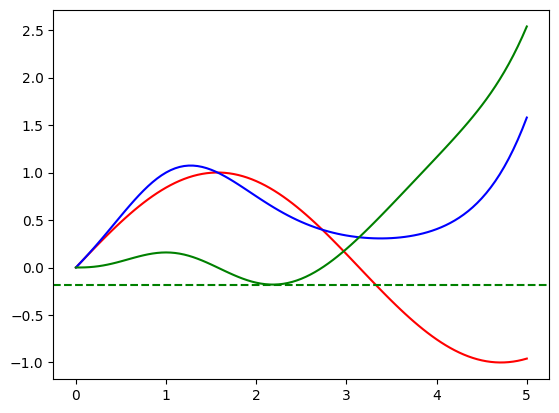

In [3]:
# Do some vector computations.
y1, y2 = x.sin(), x ** x.cos()
y3 = y2 - y1
y4 = y3.min()

# Print and plot some answers.
print(f'The shape of x is {x.shape}')
print(f'The shape of y1=x.sin() is {y1.shape}')
print(f'The shape of y2=x ** x.cos() is {y2.shape}')
print(f'The shape of y3=y2 - y1 is {y3.shape}')
print(f'The shape of y4=y3.min() is {y4.shape}, a zero-d scalar')

plt.plot(x, y1, 'red', x, y2, 'blue', x, y3, 'green')
plt.axhline(y4, color='green', linestyle='--')
plt.show()

### Exercise

Plot y3 clamped between 0.0 and 1.0.

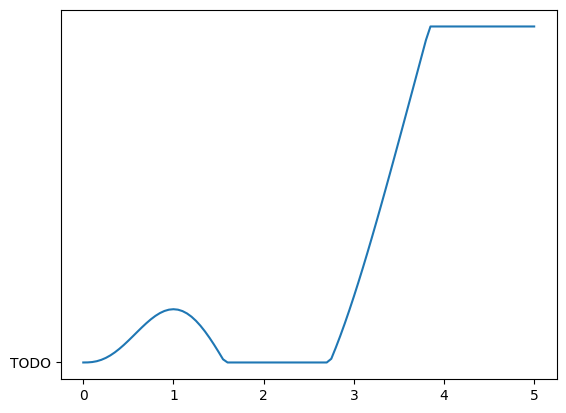

In [4]:
# TODO: Plot y3 clamped between 0.0 and 1.0.
plt.plot(x, y3.clamp(0,1))
plt.plot('TODO')
plt.show()

Subscripts and multiple dimensions
----------------------------------

**Slicing.** As normal in python, you can use `[min:max:stride]` to slice ranges, and multidimensional subscripts like `x[2,0,1,9]` work as you would expect (selecting the 9th entry of the of the 1st of the 0th of the 2nd entry of `x`; and can be used with slices like `x[0:3,2,:,:]`.  The special slice `:` selects the whole range in that dimension.

**Unsqueezing to add a dimension, and broadcasting.** While a single integer subscript like `x[0]` eliminates a dimension, the special subscript `x[None]` does the reverse and adds an extra dimension of size one.

In [5]:
import torch
from matplotlib import pyplot as plt

# Make an array of normally distributed randoms.
m = torch.randn(2, 5).abs()

print(f'column zero, m[:,0] is {m[:,0]}')
print(f'row zero m[0,:] is {m[0,:]}\n')

dot_product = (m[0,:] * m[1,:]).sum()
print(f'The dot product of rows (m[0,:] * m[1,:]).sum() is {dot_product}\n')

outer_product = m[0,:][None,:] * m[1,:][:,None]
print(f'The outer product of rows m[0,:][None,:] * m[1,:][:,None] is:\n{outer_product}')

column zero, m[:,0] is tensor([0.6640, 0.1043])
row zero m[0,:] is tensor([6.6405e-01, 1.4347e-03, 1.7756e+00, 1.2933e-01, 9.1365e-01])

The dot product of rows (m[0,:] * m[1,:]).sum() is 3.4365506172180176

The outer product of rows m[0,:][None,:] * m[1,:][:,None] is:
tensor([[6.9286e-02, 1.4969e-04, 1.8526e-01, 1.3494e-02, 9.5330e-02],
        [2.1353e-01, 4.6133e-04, 5.7094e-01, 4.1586e-02, 2.9379e-01],
        [5.5605e-01, 1.2013e-03, 1.4868e+00, 1.0829e-01, 7.6506e-01],
        [6.1459e-01, 1.3278e-03, 1.6433e+00, 1.1970e-01, 8.4561e-01],
        [1.2794e+00, 2.7642e-03, 3.4209e+00, 2.4917e-01, 1.7603e+00]])


### Exercise

Use `torch.mm` to compute `outer_product` and `dot_product`.

Explain to yourself why order matters when using torch.mm but not when using `*`.

In [6]:
# TODO Use torch.mm to compute outer_product and dot_product.

outer = torch.matmul(m[1,:][:,None], m[0,:][None,:])
print(outer == outer_product)
dot = torch.dot(m[0,:], m[1,:])
print(dot == dot_product)

tensor([[True, True, True, True, True],
        [True, True, True, True, True],
        [True, True, True, True, True],
        [True, True, True, True, True],
        [True, True, True, True, True]])
tensor(False)


**Devices** and types
-----------------

One of the big reasons to use pytorch instead of numpy is that pytorch can do computations on the GPU.  But because moving data on and off of a GPU device is more expensive than keeping it within the device, pytorch treats a Tensor's **computing device** as pseudo-type that requires explicit declaration and explicit conversion.

**Single precision CPU default.** By default a torch tensor will be stored on the CPU and will store single-precision 32-bit `torch.float` values.

**Specifying data type.** To store a different data type such as integers, use the argument `dtype=torch.long` when you create the Tensor.  For example, `z = torch.zeros(10, dtype=torch.long)`.

**Specifying GPU.** To store the tensor on the GPU, specify `device='cuda'` when you make it, for example `identity_matrix = torch.eye(5, device='cuda')`.

**Copying a tensor to a different device or type.** You cannot directly combine tensors that are on different devices (e.g., GPU vs CPU or different GPUs); this is similar to how most different-data-type combinations are also prohibited. In both cases you will need to convert types and move devices explicitly to make tensors compatible before combining them.  The `x.to(y.device)` or `x.to(y.dtype)` function can be used to do the conversion.

**float is fastest.** All commodity GPU hardware is fast at single-precision 32-bit floating-point math, about 20x CPU speed.  Be aware that only expensive cards are fast at 64-bit double-precision math.

So `float` is the default and usually the best.

An example of some CPU versus GPU speed comparisons is below.

Visit the https://pytorch.org/get-started/locally/ .

Choose your operating system, the package manager you're using (pip, conda, etc.), and the appropriate CUDA version (usually either CUDA 11.x or CUDA 12.x, depending on your GPU and driver version).

In [7]:
import torch
print(torch.cuda.is_available())

False


In [8]:
import torch, time
from matplotlib import pyplot as plt

# Here is a demonstration of moving data between GPU and CPU.
# We multiply a batch of vectors through a big linear opeation 10 times
r = torch.randn(1024, 1024, dtype=torch.float)
x = torch.randn(32768, 1024, dtype=r.dtype)
iterations = 10

def time_iterated_mm(x, matrix):
    start = time.time()
    result = 0
    for i in range(iterations):
        result += torch.mm(matrix, x.to(matrix.device).t())
    torch.cuda.synchronize()
    elapsed = time.time() - start
    return elapsed, result.cpu()

cpu_time, cpu_result = time_iterated_mm(x.cpu(), r.cpu())
print(f'time using the CPU alone: {cpu_time:.3g} seconds')

mixed_time, mixed_result = time_iterated_mm(x.cpu(), r.cuda())
print(f'time using GPU, moving data from CPU: {mixed_time:.3g} seconds')

pinned_time, pinned_result = time_iterated_mm(x.cpu().pin_memory(), r.cuda())
print(f'time using GPU on pinned CPU memory: {pinned_time:.3g} seconds')

gpu_time, gpu_result = time_iterated_mm(x.cuda(), r.cuda())
print(f'time using the GPU alone: {gpu_time:.3g} seconds')

plt.figure(figsize=(4,2), dpi=150)
plt.ylabel('iterations per sec')
plt.bar(['cpu', 'mixed', 'pinned', 'gpu'],
        [iterations/cpu_time,
         iterations/mixed_time,
         iterations/pinned_time,
         iterations/gpu_time])
plt.show()

print(f'Your GPU is {cpu_time / gpu_time:.3g}x faster than CPU'
      f' but only {cpu_time / mixed_time:.3g}x if data is repeatedly copied from the CPU')
print(f'When copying from pinned memory, speedup is {cpu_time / pinned_time:.3g}x')
print(f'Numerical differences between GPU and CPU: {(cpu_result - gpu_result).norm() / cpu_result.norm()}')

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

### Exercise

Repeat the benchmark using type `torch.double`.   What does that tell you about your GPU hardware?

In [ ]:
# TODO: Repeat the benchmark using type torch.double.
r = 'TODO'
x = 'TODO'

# Benchmark and plot

pytorch Tensor dimension-ordering conventions
---------------------------------------------

Separate tensors can be put together into a single batch tensor using `torch.cat([a, b, c])` or `torch.stack([a, b, c])`.  (The difference: `cat` doesn't add any new dimensions but just concatenates along the existing 0th dimension.  `stack` adds a new 0th dimension for the batch.)

**Multidimensional linear operation convention.** When storing matrix weights or convolution weights, linear algebra conventions are followed
* Dimension 0 (number of rows) matches the output channel dimension
* Dimension 1 (number of columns) matches the input channel dimension
* Dimension 2 (if present) is the convolutional kernel y-dimension
* Dimension 3 (if present) is the convolutional kernel x-dimension

**Permute and view reshape an array without moving memory.** The `permute` and `view` methods are useful for rearranging, flattening, and unflatteneing axes. `x.permute(1,0,2,3).view(x.shape[1], -1)`.  They just alter the view of the block of numbers in memory without moving any of the numbers around, so they are fast.

**Reshaping sometimes needs copying.** Some sequences of axis permutations and flattenings cannot be done without copying the data into the new order in memory; the `x.contiguous()` method copies the data iinto the natural order given by the current view; also `x.reshape()` is similar to `view` but will makes a copy if necessary so you do not need to think about it.

Use torch.randn to create a four-dimensional tensor x of size (2,3,4,5), which could store two 5x4 RGB images.

Then print three things:

print x.
Use x.permute to switch the horizontal and vertical (last two) dimensions.
Use x.view to see each image as a flat vector of 60 numbers.

In [12]:
# TODO make x of size (2,3,4,5), and print three rearrangements of x
x = torch.randn(2,3,4,5)
print(x)
print(x.reshape(3,2,5,4))
print(x.permute(3,2,1,0))


tensor([[[[ 3.9125e-01,  1.1236e+00, -1.5151e-01, -9.6909e-01, -1.1302e+00],
          [ 1.0305e-01,  1.8167e+00, -8.3666e-01,  4.7338e-01, -8.3977e-02],
          [-3.4685e-01,  3.3015e-01, -1.8940e+00, -7.0516e-01,  1.5324e+00],
          [-1.2078e+00, -2.3560e-03, -1.2342e+00, -6.9123e-01,  1.7125e-01]],

         [[-4.1531e-01, -1.9176e+00, -2.1678e+00,  2.0320e+00,  7.8264e-01],
          [ 1.1014e+00, -4.0060e-01,  1.1864e+00, -5.9449e-01, -1.0914e-01],
          [-3.7299e-01, -9.5463e-01,  1.4654e+00, -8.1719e-01, -1.7534e+00],
          [-1.9019e-01,  1.1428e+00,  1.5151e+00, -5.2267e-01, -4.1968e-01]],

         [[ 1.5134e-01,  8.1252e-01, -7.9199e-01,  4.8047e-01,  1.1859e+00],
          [-1.2181e+00, -3.9056e-01, -7.4111e-01,  9.1047e-01,  2.8560e-01],
          [-6.1572e-01,  8.9124e-01,  1.4447e+00, -3.2583e-01, -1.3045e+00],
          [-5.9922e-01, -1.9130e+00,  2.6971e-01,  9.5685e-01, -1.3073e+00]]],


        [[[ 1.4111e-01, -1.0584e+00, -1.3932e+00, -3.2876e-01, -6.78

Topic 2: Pytorch Autograd
================

If you flag a torch Tensor with the attribute `x.requires_grad=True`, then pytorch will automatically keep track the computational history of all tensors that are derived from `x`.  This allows pytorch to figure out derivatives of any scalar result with regard to changes in the components of x.

The function `torch.autograd.grad(output_scalar, [list of input_tensors])` computes `d(output_scalar)/d(input_tensor)` for each input tensor component in the list.  For it to work, the input tensors and output must be part of the same `requires_grad=True` compuation.

In the example here, `x` is explicitly marked `requires_grad=True`, so `y.sum()`, which is derived from `x`, automatically comes along with the computation history, and can be differentiated.

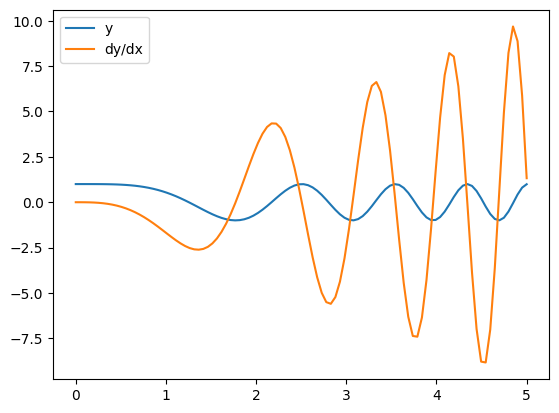

In [13]:
import torch
from matplotlib import pyplot as plt

x = torch.linspace(0, 5, 100,
          requires_grad=True)
y = (x**2).cos()
s = y.sum()
[dydx] = torch.autograd.grad(s, [x])

plt.plot(x.detach(), y.detach(), label='y')
plt.plot(x.detach(), dydx, label='dy/dx')
plt.legend()
plt.show()

### Exercise

Plot the polynomial y=x<sup>3</sup>-6x<sup>2</sup>+8x and its derivative, instead of cos(x<sup>2</sup>).

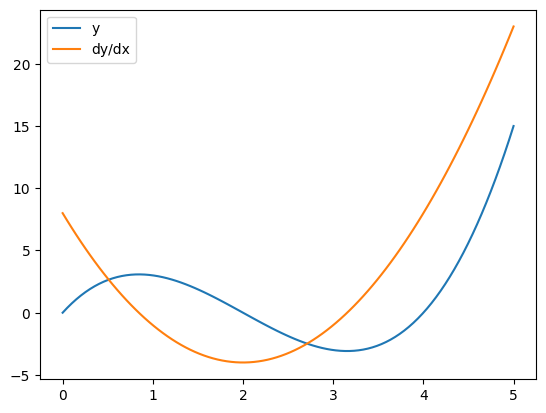

In [14]:
# TODO: set y to the given polynomial of x
y = x**3 - 6*x**2 + 8*x

# TODO: use autograd to compute the derivative
[dydx] = torch.autograd.grad(y.sum(), [x])
# TODO: plot the results.
plt.plot(x.detach(), y.detach(), label='y')
plt.plot(x.detach(), dydx, label='dy/dx')
plt.legend()
plt.show()

Backprop and In-place gradients
-------------------------------

In a typical neural network we will not just be getting gradients with regard to one input like `x` above, but with regard to a list of dozens or hundreds of tensor parameters that have all been marked with `requires_grad=True`.

**Using `backward()` to add `.grad` attributes.** To simplify this common operation, pytorch provides the `y.backward()` method, which computes the gradients of y with respect to every tracked dependency, and stores the results in the field `x.grad` for every original input vector `x` that was marked as `requires_grad=True`.

tensor([-0.0000e+00, -2.5765e-04, -2.0612e-03, -6.9560e-03, -1.6485e-02,
        -3.2185e-02, -5.5575e-02, -8.8145e-02, -1.3133e-01, -1.8650e-01,
        -2.5487e-01, -3.3752e-01, -4.3528e-01, -5.4869e-01, -6.7791e-01,
        -8.2262e-01, -9.8193e-01, -1.1543e+00, -1.3373e+00, -1.5279e+00,
        -1.7218e+00, -1.9138e+00, -2.0978e+00, -2.2665e+00, -2.4118e+00,
        -2.5246e+00, -2.5954e+00, -2.6144e+00, -2.5720e+00, -2.4592e+00,
        -2.2684e+00, -1.9940e+00, -1.6330e+00, -1.1861e+00, -6.5843e-01,
        -5.9786e-02,  5.9438e-01,  1.2829e+00,  1.9791e+00,  2.6508e+00,
         3.2620e+00,  3.7737e+00,  4.1467e+00,  4.3434e+00,  4.3315e+00,
         4.0872e+00,  3.5983e+00,  2.8676e+00,  1.9159e+00,  7.8273e-01,
        -4.7262e-01, -1.7729e+00, -3.0265e+00, -4.1327e+00, -4.9894e+00,
        -5.5028e+00, -5.5970e+00, -5.2252e+00, -4.3782e+00, -3.0925e+00,
        -1.4526e+00,  4.1007e-01,  2.3249e+00,  4.0956e+00,  5.5192e+00,
         6.4094e+00,  6.6222e+00,  6.0798e+00,  4.7

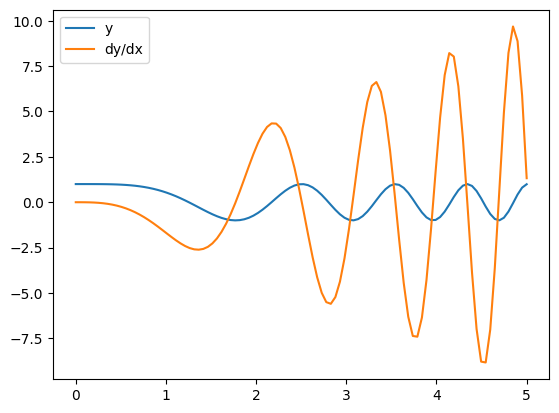

In [15]:
x = torch.linspace(0, 5, 100, requires_grad=True)
y = (x**2).cos()
y.sum().backward()   # populates the grad attribute below.
print(x.grad)

plt.plot(x.detach(), y.detach(), label='y')
plt.plot(x.detach(), x.grad, label='dy/dx')
plt.legend()
plt.show()

### Exercise

1. Introduce a new vector x<sub>2</sub> which also ranges from zero to five (same as x, but not cloned from x).
2. Plot the polynomial y=x<sub>2</sub><sup>3</sup>-6x<sup>2</sup>+8x
3. Plot dy/dx and dy/dx<sub>2</sub>.

Which x contributes most to the gradient at zero?  At five?

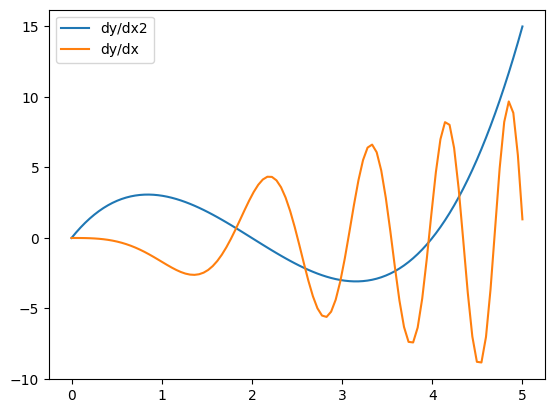

In [17]:
# TODO: define x2 just like x, but not cloned from x
x2 = torch.linspace(0, 5, 100, requires_grad=True)
y = x2**3-(6*x**2)+8*x
# TODO: Plot the given polynomial which depends on both x and x2
plt.plot(x2.detach(), y.detach(), label='dy/dx2')
plt.plot(x.detach(), x.grad, label='dy/dx')
plt.legend()
plt.show()
# TODO: Plot both dy/dx and dy/dx2.  Explain what you get.


Pytorch Optimizers
==================

Optimizers have a simple job: given gradients of an objective with respect to a set of input parameters, adjust the parameters reduce the objective.  They do this by modifying each parameter by a small amount in the direction given by the gradient.

Gradient descent just subtracts the gradient
---------
You can apply gradient descent by hand easily by just using `loss.backward()` to compute the gradient of the loss with respect to every parameter `x`, and then apply `x -= learning_rate * x.grad` to nudge `x` in the gradient direction that makes the loss smaller.

Run this cell to setup visualization...

In [18]:
#@title Run this cell to setup visualization...
# This cell defines plot_progress() which plots an optimization trace.

import matplotlib
from matplotlib import pyplot as plt

def plot_progress(bowl, track, losses):
    # Draw the contours of the objective function, and x, and y
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 5))
    for size in torch.linspace(0.1, 1.0, 10):
        angle = torch.linspace(0, 6.3, 100)
        circle = torch.stack([angle.sin(), angle.cos()])
        ellipse = torch.mm(torch.inverse(bowl), circle) * size
        ax1.plot(ellipse[0,:], ellipse[1,:], color='skyblue')
    track = torch.stack(track).t()
    ax1.set_title('progress of x')
    ax1.plot(track[0,:], track[1,:], marker='o')
    ax1.set_ylim(-1, 1)
    ax1.set_xlim(-1.6, 1.6)
    ax1.set_ylabel('x[1]')
    ax1.set_xlabel('x[0]')
    ax2.set_title('progress of y')
    ax2.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
    ax2.plot(range(len(losses)), losses, marker='o')
    ax2.set_ylabel('objective')
    ax2.set_xlabel('iteration')
    fig.show()

from IPython.display import HTML
HTML('''<script>function toggle_code(){$('.rendered.selected div.input').toggle().find('textarea').focus();} $(toggle_code())</script>
<a href="javascript:toggle_code()">Toggle</a> the code for plot_progress.''')

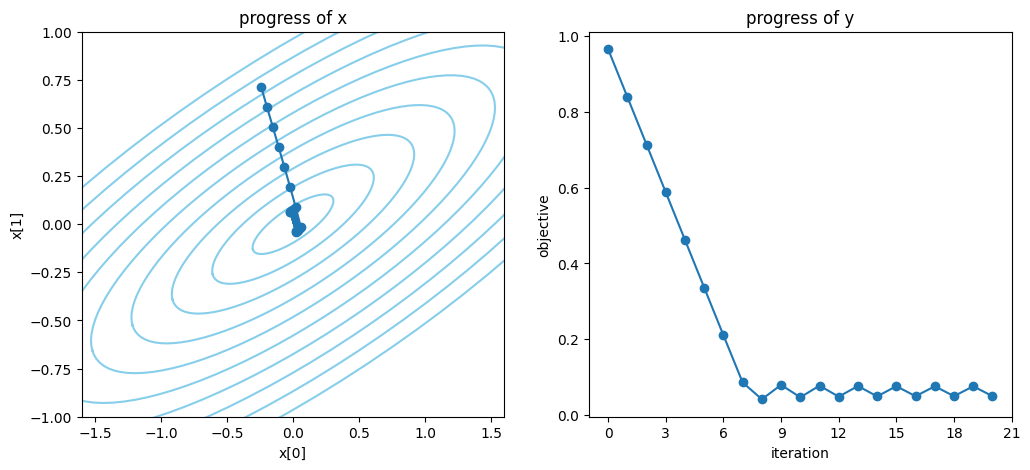

In [19]:
import torch

x_init = torch.randn(2)
x = x_init.clone()

bowl = torch.tensor([[ 0.4410, -1.0317], [-0.2844, -0.1035]])
track, losses = [], []

for iter in range(21):
    x.requires_grad = True
    loss = torch.mm(bowl, x[:,None]).norm()
    loss.backward()
    with torch.no_grad():
        x = x - 0.1 * x.grad
    track.append(x.detach().clone())
    losses.append(loss.detach())

plot_progress(bowl, track, losses)

Built-in optimization algorithms
------

Pytorch includes several optimization algorithms.The actual optmization algorithms employ a number of techniques to make the process faster and more robust as repeated steps are taken. The simplest method is SGD-with-momentum, which is implemented in pytorch as `pytorch.optim.SGD`.

To use SGD, you need to calculate your objective and fill in gradients on all the parameters before it can take a step.

  1. Set your parameters (x in this case) to `x.requires_grad = True` so autograd tracks them (line 5).
  2. Create the optimizer and tell it about the parameters to adjust (`[x]` here) (line 6).
  3. In a loop, compute your objective, then call `loss.backward()` to fill in `x.grad` and then `optimizer.step()` to adjust `x` accordingly (lines 12-15).
  
**Remember to zero gradient.** Notice that we use `optimizer.zero_grad()` each time to set x.grad to zero before recomputing gradients; if we do not do this, then the new gradient will be added to the old one.

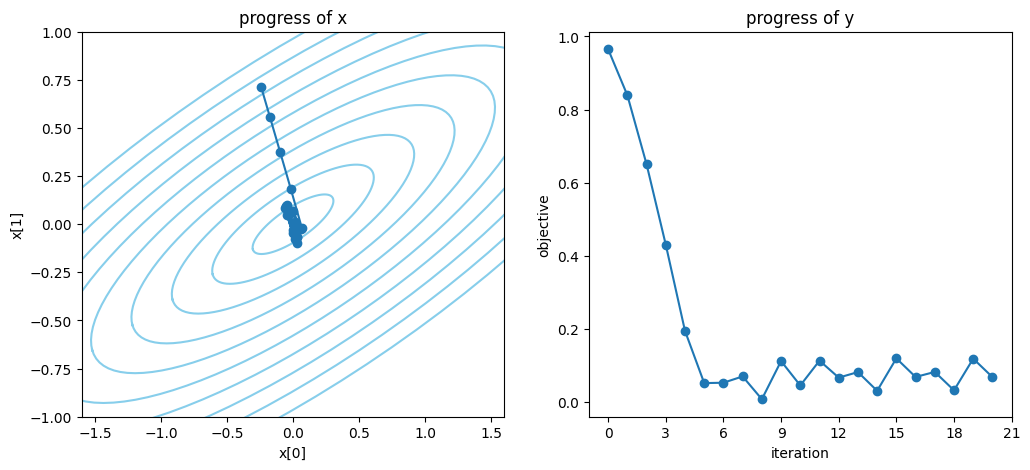

In [20]:
import torch

x = x_init.clone()
x.requires_grad = True
optimizer = torch.optim.SGD([x], lr=0.1, momentum=0.5)

bowl = torch.tensor([[ 0.4410, -1.0317], [-0.2844, -0.1035]])
track, losses = [], []

for iter in range(21):
    loss = torch.mm(bowl, x[:,None]).norm()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    track.append(x.detach().clone())
    losses.append(loss.detach())

plot_progress(bowl, track, losses)

### Exercise

1. Set the `x_init` fixed, to the point `torch.tensor([-1.0, 0.0])`.
2. Increase the number of iterations to 101.
3. Experiment with different combinations of `lr` and `momentum` to see which converges to zero `y` best.

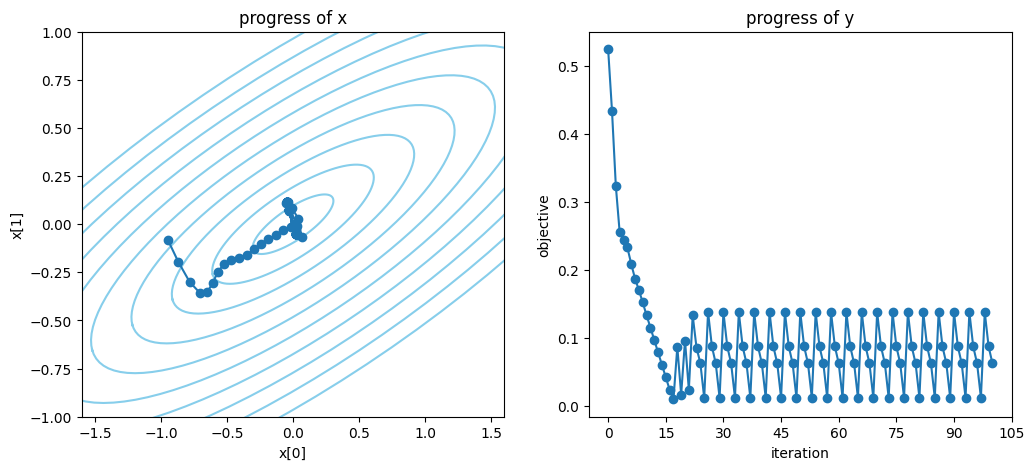

In [22]:
# TODO: Copy the SGD cell above, and modify it to
# 1. set x_init to [-1, 0]
x_init = torch.tensor([-1.0, 0.0])
x = x_init.clone()
x.requires_grad = True
optimizer = torch.optim.SGD([x], lr=0.1, momentum=0.5)

bowl = torch.tensor([[ 0.4410, -1.0317], [-0.2844, -0.1035]])
track, losses = [], []

for iter in range(101):
  loss = torch.mm(bowl, x[:,None]).norm()
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  track.append(x.detach().clone())
  losses.append(loss.detach())
plot_progress(bowl, track, losses)
# 2. Increase iterations to 101
# 3. Find settings for lr and momenum that get the lowest objective

Using other optimizers
----------------------

Other optimizers are similar.  Adam is a popular adaptive method that does well without much tuning, and can be dropped in to replace plain SGD.

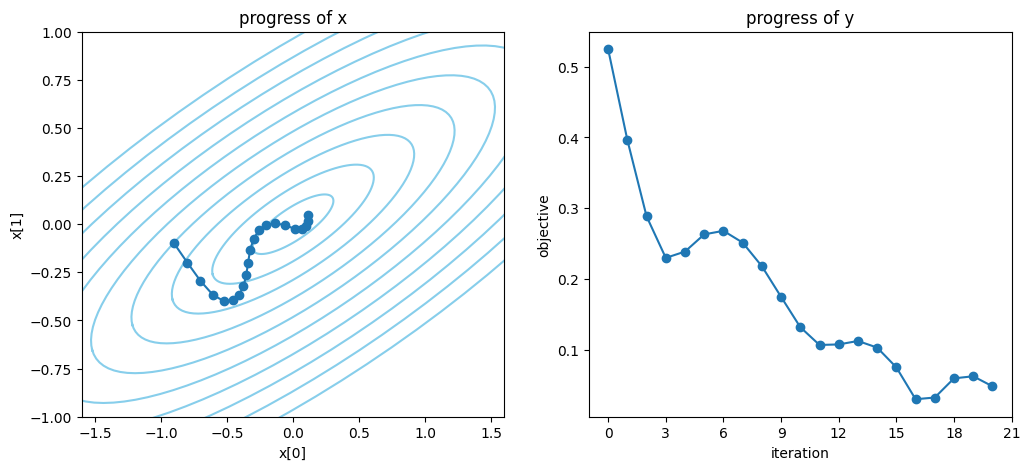

In [23]:
# The code below uses Adam
x = x_init.clone()
x.requires_grad = True
optimizer = torch.optim.Adam([x], lr=0.1)

track, losses = [], []

for iter in range(21):
    loss = torch.mm(bowl, x[:,None]).norm()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    track.append(x.detach().clone())
    losses.append(loss.detach())

plot_progress(bowl, track, losses)

Pytorch Neural Network Modules
==============================

Pytorch uses the `torch.nn.Module` class to represent a neural network.

A `Module` is just a **callable** function that can be:

 * **Parameterized** by trainable `Parameter` tensors that the module can list out.
 * **Composed** out of children `Module`s that contribute parameters.
 * **Saved and Loaded** by listing named parameters and other attribute buffers.

Pytorch comes with several built-in elementary network modules, like a generic single-layer `Linear` network, or a generic `Sequential` composition of other networks, but of course you can write your own `Module`.

Let's look at how to use the built-in `Linear` and `Sequential` modules.

Using torch.nn.Linear as a Neural Network
=========================================

The linear layer is the fundmental workhorse of all neural networks, so as simple as it is, it is worth examining carefully.

`torch.nn.Linear` implements the function `y = Ax + b`, which takes m-dimensional input `x` and produces n-dimensional output `y`, by multiplying by the n &times; m matrix `A` (whose specific values are called the `weight`) and adding n-dimensional vector `b` (whose values are called the `bias`).  We can make a Linear network with 3d input and 2d output just like this:

In [24]:
import torch
net = torch.nn.Linear(3, 2)
print(net)

Linear(in_features=3, out_features=2, bias=True)


Like any Module, our little network can be run as a function. As expected, when we give it 3-d vector as input, we get a 2-d vector as output.

In [25]:
net(torch.tensor([[1.0, 0.0, 0.0]]))

tensor([[-0.3776,  0.1943]], grad_fn=<AddmmBackward0>)

Batchwise processing is assumed in pytorch networks. Notice the double nesting in the vector data above. This is needed because our Linear network is slightly different from a plain matrix-vector multiplication. By convention, pytorch Modules are set up to process data in batches, so to give it a single 3-d vector, instead of passing just a vector, we have passed it a singleton batch containing one vector.

We can instead send in several inputs - here we provide four vectors as inputs. The network then gives us four vectors as outputs:

In [26]:
x_batch = torch.tensor([
    [1.0, 0. , 0. ],
    [0. , 1.0, 0. ],
    [0. , 0. , 1.0],
    [0. , 0. , 0. ],
])
net(x_batch)

tensor([[-0.3776,  0.1943],
        [ 0.2435,  0.2365],
        [ 0.2649,  0.2666],
        [ 0.0360, -0.1780]], grad_fn=<AddmmBackward0>)

Parameters are randomly initializated by default. What strange function is this Linear layer computing? By default pytorch has initialized the weights and bias randomly. We can look at these random parameters directly:

In [27]:
print('weight is', net.weight)
print('bias is', net.bias)

weight is Parameter containing:
tensor([[-0.4136,  0.2075,  0.2289],
        [ 0.3722,  0.4144,  0.4446]], requires_grad=True)
bias is Parameter containing:
tensor([ 0.0360, -0.1780], requires_grad=True)


### Exercise

1. Set the `bias` of the network to the zero vector.
2. Examine the numerical results of `net(x_batch)`.  Do the answers match the parameters as you would expect?

**Hint**: although `x.zero_()` or `x[:] = 0.0` can zero a vector in place, since the network parameters are all `requires_grad=True`, you will need to put things in a `with torch.no_grad()` block to temporarily disable autograd before changing the values.

In [29]:
# TODO: Set the bias of the network to the zero vector.
with torch.no_grad():
  net.bias[:] = 0.0
# TODO: Compare the numerical results of net(x_batch) to the parameters.
net(x_batch)

tensor([[-0.4136,  0.3722],
        [ 0.2075,  0.4144],
        [ 0.2289,  0.4446],
        [ 0.0000,  0.0000]], grad_fn=<AddmmBackward0>)

In [30]:
for name, param in net.named_parameters():
    print(f'{name} = {param}\n')

weight = Parameter containing:
tensor([[-0.4136,  0.2075,  0.2289],
        [ 0.3722,  0.4144,  0.4446]], requires_grad=True)

bias = Parameter containing:
tensor([0., 0.], requires_grad=True)



Training Example: Optimizing a Linear Layer
-------------------------------------------

To train a network we need to come up with a score for how close we are to the goal.  This scalar number is called the **objective** or the **loss**.

For example, suppose we would like this network to always output `[1, 1]` regardless of input.  Then a reasonable loss would be the mean squared distance to `[1, 1]`, computed like this:

In [31]:
y_batch = net(x_batch)
loss = ((y_batch - torch.tensor([[1.0, 1.0]])) ** 2).sum(1).mean()
print(f'loss is {loss}')

loss is 1.5665431022644043


**Simple gradient descent can be done directly.**  To improve our layer, we can use simple gradient descent with a learning rate of 0.01.  That is, we can adjust each parameter by subtracting 0.01 times the gradient.  If we do this repeatedly, we should get closer to our objective.

Any time we directly update the network parameters, we need to temporarily disable the autograd machinery using `with torch.no_grad()`.

weight is Parameter containing:
tensor([[1.0989e-05, 1.0989e-05, 1.0989e-05],
        [1.1901e-05, 1.1901e-05, 1.1901e-05]], requires_grad=True)

bias is Parameter containing:
tensor([1.0000, 1.0000], requires_grad=True)



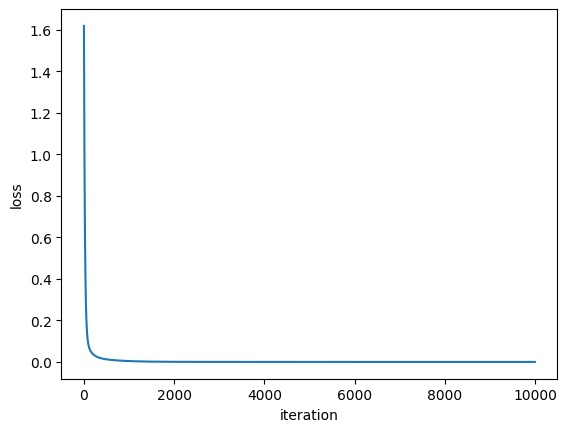

In [32]:
net = torch.nn.Linear(3, 2)
log = []
for _ in range(10000):
    y_batch = net(x_batch)
    loss = ((y_batch - torch.tensor([[1.0, 1.0]])) ** 2).sum(1).mean()
    log.append(loss.item())
    net.zero_grad()
    loss.backward()
    with torch.no_grad():
        for p in net.parameters():
            p[...] -= 0.01 * p.grad
print(f'weight is {net.weight}\n')
print(f'bias is {net.bias}\n')

%matplotlib inline
import matplotlib.pyplot as plt
plt.ylabel('loss')
plt.xlabel('iteration')
plt.plot(log)
plt.show()

### Exercise

1. Use `plt.yscale('log')` to plot the loss on a log scale.
2. Look directly at `net.bias` and use subtraction to see how far it is from (1,1).

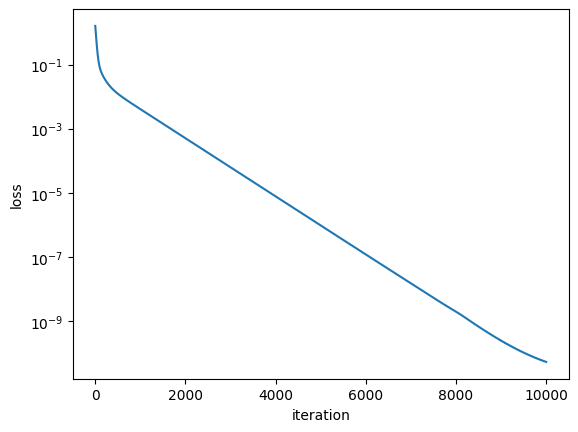

Parameter containing:
tensor([1.0000, 1.0000], requires_grad=True)
tensor([-9.7156e-06, -1.0371e-05], grad_fn=<SubBackward0>)


In [33]:
# TODO: Plot the evolution of the loss on a log scale.
plt.yscale('log')
plt.ylabel('loss')
plt.xlabel('iteration')
plt.plot(log)
plt.show()
# TODO: Examine net.bias directly and compare to (1,1)
print(net.bias)
print(net.bias - torch.tensor([1.0, 1.0]))

Voila, we have trained a simple neural network to our desired objective of outputting a constant ones vector.  After a few thousand updates, the weight has a near-zero matrix, and the bias becomes `[1.0, 1.0]`, as desired.

**A realistic training loop would run on the GPU using bigger batches of randomized input and a prepackaged optimization algorithm.**

Below we create a newly randomized `Linear` net instance, and train it on the GPU using the Adam optimizer fo 1000 iterations.

weight is Parameter containing:
tensor([[-9.7914e-09, -2.7083e-08,  1.3082e-08],
        [-1.1533e-08, -3.2268e-09,  1.0997e-08]], requires_grad=True)

bias is Parameter containing:
tensor([1.0000, 1.0000], requires_grad=True)



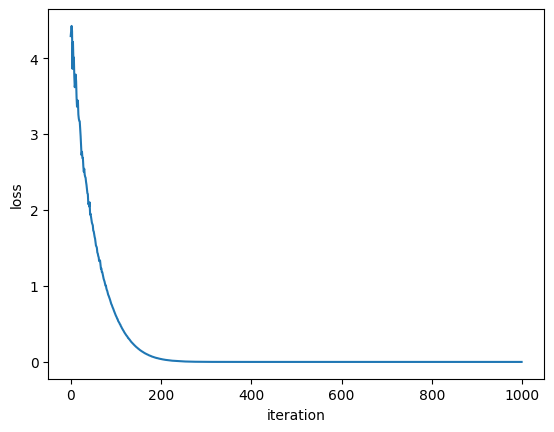

In [34]:
from torch.optim import Adam
net = torch.nn.Linear(3, 2)
optimizer = Adam(net.parameters(), lr=0.01)
# Move the network, target value, and training inputs to the GPU
net.cpu()
target = torch.tensor([[1.0, 1.0]], device='cpu')
log = []
for _ in range(1000):
    y_batch = net(torch.randn(100, 3, device='cpu'))
    loss = ((y_batch - target) ** 2).sum(1).mean()
    log.append(loss.item())
    net.zero_grad()
    loss.backward()
    optimizer.step()
print(f'weight is {net.weight}\n')
print(f'bias is {net.bias}\n')

%matplotlib inline
import matplotlib.pyplot as plt
plt.ylabel('loss')
plt.xlabel('iteration')
plt.plot(log)

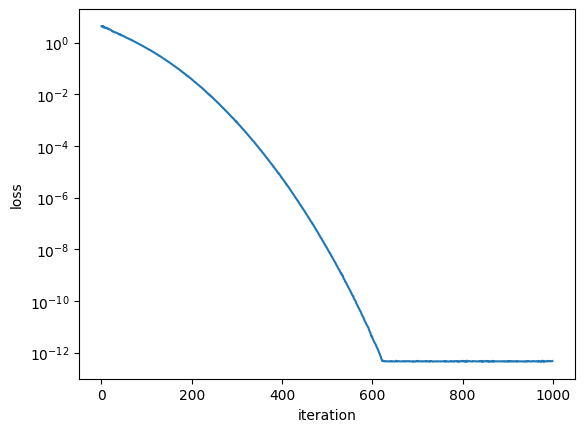

Parameter containing:
tensor([1.0000, 1.0000], requires_grad=True)


In [35]:
# TODO: Plot the evolution of the loss on a log scale again.
plt.yscale('log')
plt.ylabel('loss')
plt.xlabel('iteration')
plt.plot(log)
plt.show()
# TODO: Examine net.bias directly.  How does Adam doo?
print(net.bias)

In [36]:
# This visulaization function is used for the next example

%matplotlib inline
from matplotlib import pyplot as plt

def visualize_net(net, classify_target):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    grid = torch.stack([
        torch.linspace(-2, 2, 100)[None, :].expand(100, 100),
        torch.linspace(2, -2, 100)[:, None].expand(100, 100),
    ])
    x, y = grid
    target = classify_target(x, y)
    ax1.set_title('target')
    ax1.imshow(target.float(), cmap='hot', extent=[-2,2,-2,2])
    ax2.set_title('network output')
    score = net(grid.permute(1, 2, 0).reshape(-1, 2)).softmax(1)
    ax2.imshow(score[:,1].reshape(100, 100).detach().cpu(), cmap='hot', extent=[-2,2,-2,2])
    plt.show()

from IPython.display import HTML
HTML('''<script>function toggle_code(){$('.rendered.selected div.input').toggle().find('textarea').focus();} $(toggle_code)</script>
<a href="javascript:toggle_code()">Toggle</a> the code for visualize_net.''')

Using torch.nn.Sequential to Compose Networks
---------------------------------------------

Unlike `Linear`, most networks are made by composing many smaller networks.  The simplest way to do this is chain networks together end-to-end, connecting each output to the next input.  For example we can simply compose `Linear` layers.

**Defining a Multilayer Perceptron.** Of course, to get something more interesting than another linear function, we need to do something nonlinear between the linear steps.  if we add a nonlinearity between each step (for example, if we clamp negative numbers to zero - an operation called `ReLU`), then we can get a **Multilayer Perceptron,** which is known to be a universal function approximator.


Here is how we can express the network as a nested set of Sequentials.

In [37]:
from collections import OrderedDict
from torch.nn import Linear, ReLU, Sequential

mlp = torch.nn.Sequential(OrderedDict([
    ('layer1', Sequential(Linear(2, 20), ReLU())),
    ('layer2', Sequential(Linear(20, 20), ReLU())),
    ('layer3', Sequential(Linear(20, 2)))
]))

print(mlp)

Sequential(
  (layer1): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): ReLU()
  )
  (layer2): Sequential(
    (0): Linear(in_features=20, out_features=20, bias=True)
    (1): ReLU()
  )
  (layer3): Sequential(
    (0): Linear(in_features=20, out_features=2, bias=True)
  )
)


In the above, we have nested two levels of Sequentials.  In the outermost level, we have defined and named three layers.

Then each layer is itself a Sequential that executes a parameterized `Linear` operation followed by a `ReLU` nonlinear clamping operation.  We have not bothered to name each of the innermost steps, so the Sequential just automatically numbers them.

**Every submodule has a fully qualified name.** We can get a full recursive list of submodules by listing `net.named_modules()`.

In [38]:
for n, c in mlp.named_modules():
    print(f'{n or "The whole network"} is a {type(c).__name__}')

The whole network is a Sequential
layer1 is a Sequential
layer1.0 is a Linear
layer1.1 is a ReLU
layer2 is a Sequential
layer2.0 is a Linear
layer2.1 is a ReLU
layer3 is a Sequential
layer3.0 is a Linear


**A module's parameters include all its child module parameters.** We can see this by listing all the parameters by name.

In [39]:
for name, param in mlp.named_parameters():
    print(f'{name} has shape {tuple(param.shape)}')

layer1.0.weight has shape (20, 2)
layer1.0.bias has shape (20,)
layer2.0.weight has shape (20, 20)
layer2.0.bias has shape (20,)
layer3.0.weight has shape (2, 20)
layer3.0.bias has shape (2,)


There are now six parameters: a weight and a bias for each of the three `Linear` layers.

**Training a Clasifier.** This slightly more complicated network can now represent a more general class of functions. For example, we can use this architecture to learn to compute a classifier function.  

Suppose we want to classify points on a plane as either above a sine-wave (class 1) or below a sine-wave (class 0). Here is the ordinary training loop to train our MLP to do it, using the Adam optimizer:


Iteration 0 accuracy: 0.5090000033378601


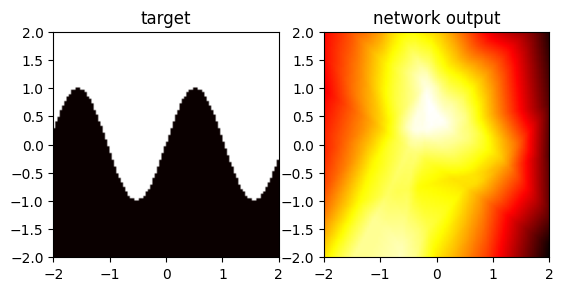

Iteration 1 accuracy: 0.49709999561309814


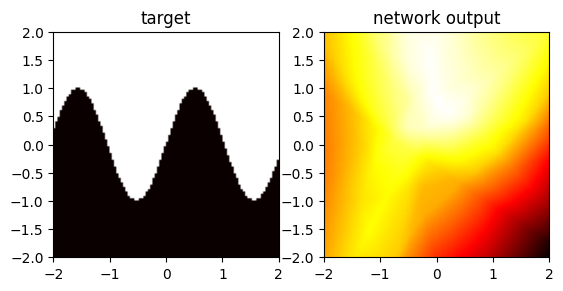

Iteration 3 accuracy: 0.520799994468689


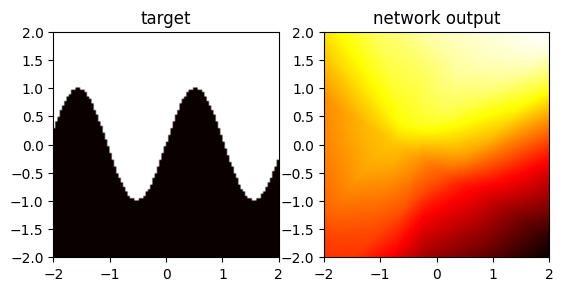

Iteration 7 accuracy: 0.7648000121116638


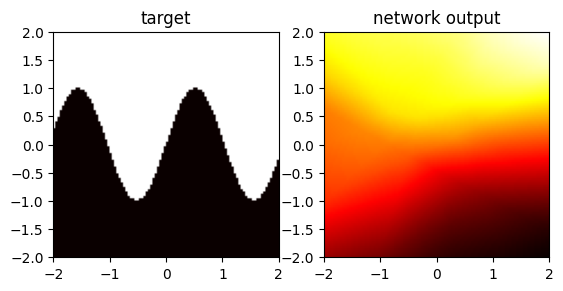

Iteration 15 accuracy: 0.7857999801635742


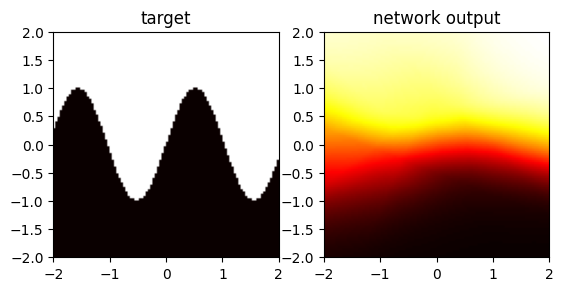

Iteration 31 accuracy: 0.8306999802589417


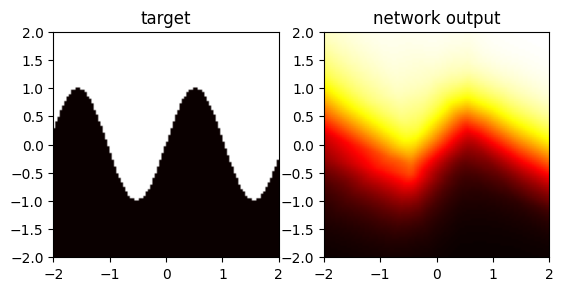

Iteration 63 accuracy: 0.9230999946594238


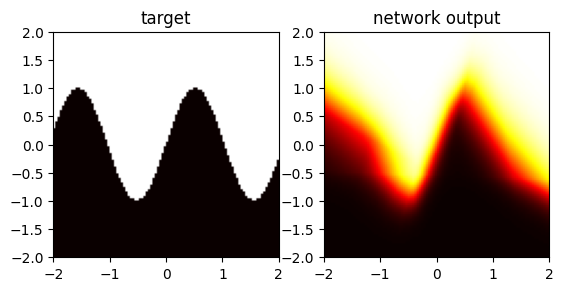

Iteration 127 accuracy: 0.9668999910354614


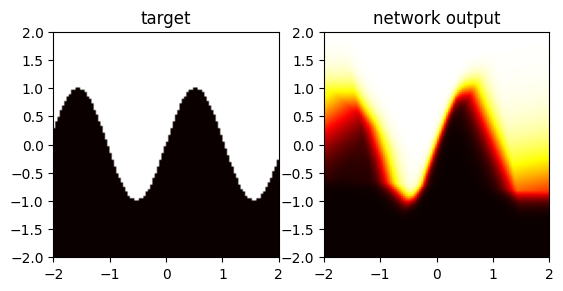

Iteration 255 accuracy: 0.986299991607666


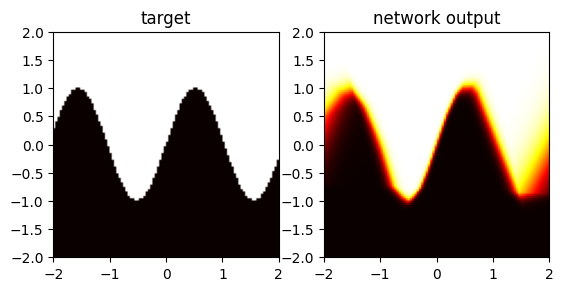

Iteration 511 accuracy: 0.9922999739646912


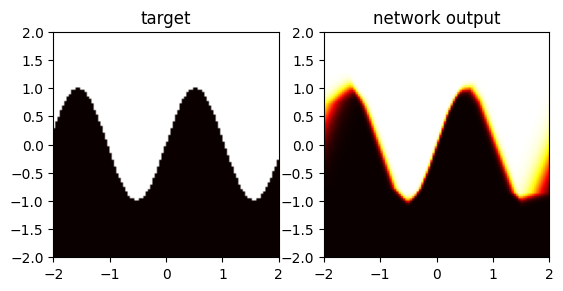

Iteration 1023 accuracy: 0.9937999844551086


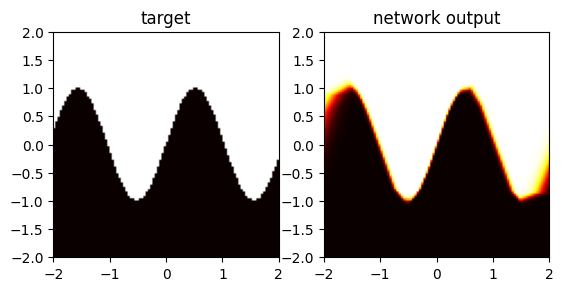

In [40]:
from torch.nn.functional import cross_entropy

def classify_target(x, y):
    return (y > (x * 3).sin()).long()

mlp.cpu()
optimizer = Adam(mlp.parameters(), lr=0.01)
for iteration in range(1024):
    in_batch = torch.randn(10000, 2, device='cpu')
    target_batch = classify_target(in_batch[:,0], in_batch[:,1])
    out_batch = mlp(in_batch)
    loss = cross_entropy(out_batch, target_batch)
    if iteration > 0:
        mlp.zero_grad()
        loss.backward()
        optimizer.step()
    if iteration == 2 ** iteration.bit_length() - 1:
        pred_batch = out_batch.max(1)[1]
        accuracy = (pred_batch == target_batch).float().sum() / len(in_batch)
        print(f'Iteration {iteration} accuracy: {accuracy}')
        visualize_net(mlp, classify_target)


### Exercise

1. Try another classification objective.  Try `(y > x**2).long()`.
2. Try another one: try `(y.floor() == x.floor()).long()`.

Iteration 0 accuracy: 0.6875


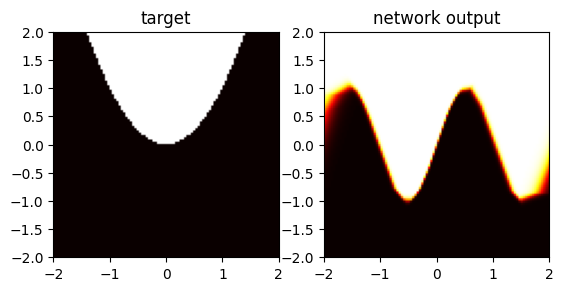

Iteration 1 accuracy: 0.6823999881744385


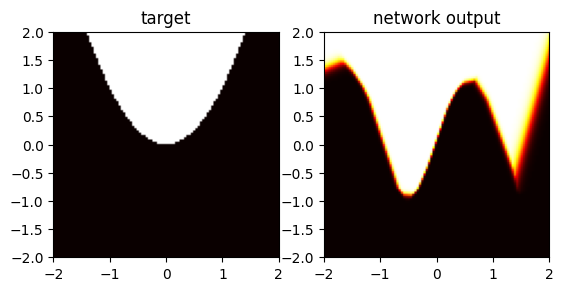

Iteration 3 accuracy: 0.8051999807357788


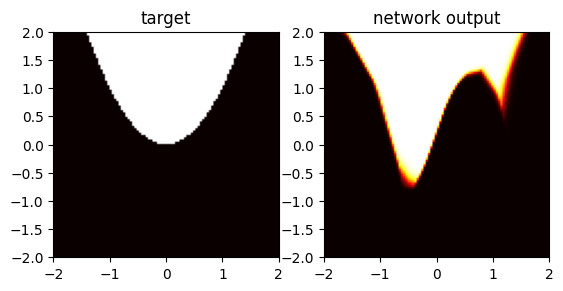

Iteration 7 accuracy: 0.8960999846458435


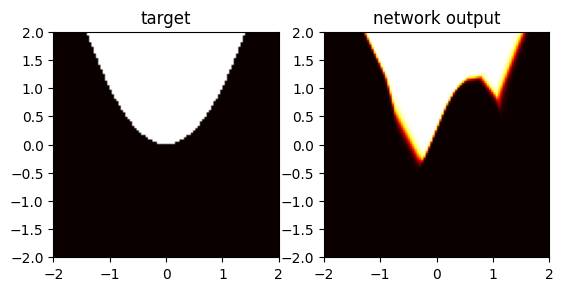

Iteration 15 accuracy: 0.8899999856948853


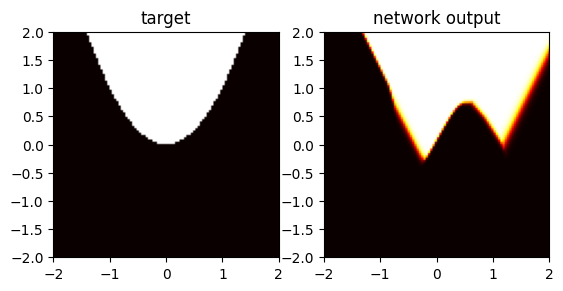

Iteration 31 accuracy: 0.9503999948501587


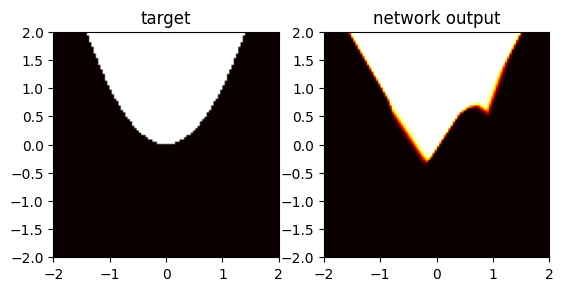

Iteration 63 accuracy: 0.975600004196167


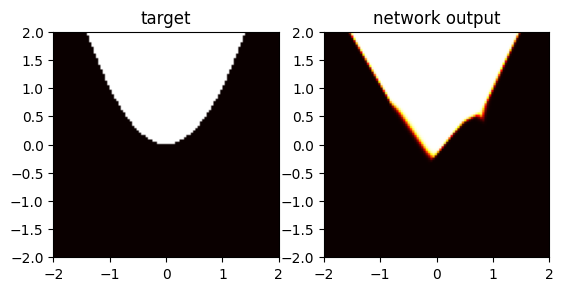

Iteration 127 accuracy: 0.9882000088691711


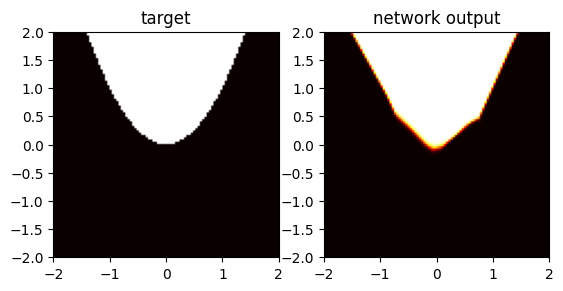

Iteration 255 accuracy: 0.9944000244140625


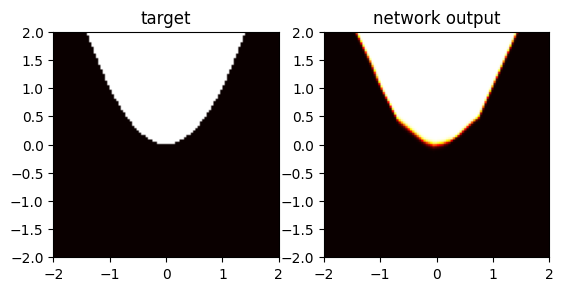

Iteration 511 accuracy: 0.996999979019165


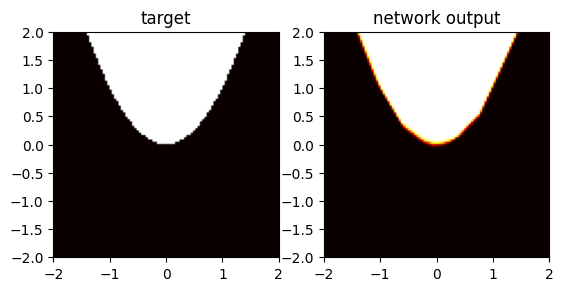

Iteration 1023 accuracy: 0.9979000091552734


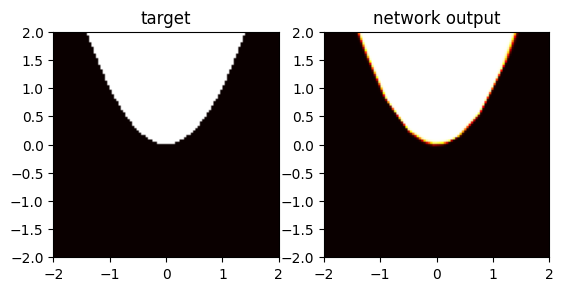

In [41]:
# TODO: repeat the experiment with `(y > x**2).long()` as the classification objective.
def classify_target(x, y):
    return (y > (x ** 2)).long()
mlp.cpu()
optimizer = Adam(mlp.parameters(), lr=0.01)
for iteration in range(1024):
    in_batch = torch.randn(10000, 2, device='cpu')
    target_batch = classify_target(in_batch[:,0], in_batch[:,1])
    out_batch = mlp(in_batch)
    loss = cross_entropy(out_batch, target_batch)
    if iteration > 0:
        mlp.zero_grad()
        loss.backward()
        optimizer.step()
    if iteration == 2 ** iteration.bit_length() - 1:
        pred_batch = out_batch.max(1)[1]
        accuracy = (pred_batch == target_batch).float().sum() / len(in_batch)
        print(f'Iteration {iteration} accuracy: {accuracy}')
        visualize_net(mlp, classify_target)
# TODO: use `(y.floor() == x.floor()).long()` as the objective.
